# A1 Dataset Preparation, Split, Interface Check and Degradation Demo

This notebook documents Member A's dataset-related work for the COMP9517 group project.

It shows:

1. How the raw iNaturalist files are expected to be placed.
2. How the fixed 500-class split was generated from the terminal.
3. How the generated split files are loaded and inspected.
4. How image paths, labels, and class distributions are checked.
5. How the shared PyTorch dataloader works.
6. How test-time image degradation examples are generated for the robustness experiment.

Important:

- The official project split is stored in `data/splits/`.
- This notebook does **not** overwrite `data/splits/`.
- The selected classes and image lists remain unchanged.
- The reusable code is kept in `src/`; this notebook is mainly for a readable walkthrough and visual evidence.


## 1. Setup

The notebook can be opened from the `notebooks/` folder or from the project root.  
The following cell automatically finds the project root and changes the working directory to it, so relative paths such as `data/splits/train_paths.csv` work consistently.


In [3]:
import sys
from pathlib import Path

print(sys.executable)
print(Path.cwd())

c:\Users\leo\anaconda3\envs\comp9517\python.exe
d:\Code\unsw\comp9517\COMP9517_Project


In [4]:
from pathlib import Path
import sys
import os
import json
import subprocess
import random

import numpy as np
import pandas as pd
from PIL import Image
import matplotlib.pyplot as plt

# Find project root
PROJECT_ROOT = Path.cwd()
if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent

sys.path.insert(0, str(PROJECT_ROOT))

print("Project root:", PROJECT_ROOT)
print("Current working directory before chdir:", Path.cwd())

# Make relative paths work consistently in notebook cells
os.chdir(PROJECT_ROOT)
print("Current working directory after chdir:", Path.cwd())

Project root: d:\Code\unsw\comp9517\COMP9517_Project
Current working directory before chdir: d:\Code\unsw\comp9517\COMP9517_Project
Current working directory after chdir: d:\Code\unsw\comp9517\COMP9517_Project


## 2. Raw data placement

The raw iNaturalist-2021 Mini files should be placed under `data/raw/`.

Expected structure:

```text
data/raw/
├── train_mini/
├── val/
├── train_mini.json
└── val.json
```

The project package does not include these raw files because they are too large.  
Each group member needs to place the raw data locally using the same structure.


In [5]:
raw_dir = PROJECT_ROOT / "data" / "raw"

expected_raw_items = [
    raw_dir / "train_mini",
    raw_dir / "val",
    raw_dir / "train_mini.json",
    raw_dir / "val.json",
]

for item in expected_raw_items:
    print(item.relative_to(PROJECT_ROOT), "exists:", item.exists())

if (raw_dir / "train_mini").exists():
    train_class_dirs = sorted([p for p in (raw_dir / "train_mini").iterdir() if p.is_dir()])
    print("\nNumber of class folders under data/raw/train_mini:", len(train_class_dirs))
    print("First 5 train_mini class folders:")
    for p in train_class_dirs[:5]:
        print(" ", p.name)

if (raw_dir / "val").exists():
    val_class_dirs = sorted([p for p in (raw_dir / "val").iterdir() if p.is_dir()])
    print("\nNumber of class folders under data/raw/val:", len(val_class_dirs))
    print("First 5 val class folders:")
    for p in val_class_dirs[:5]:
        print(" ", p.name)

data\raw\train_mini exists: True
data\raw\val exists: True
data\raw\train_mini.json exists: True
data\raw\val.json exists: True

Number of class folders under data/raw/train_mini: 10000
First 5 train_mini class folders:
  00000_Animalia_Annelida_Clitellata_Haplotaxida_Lumbricidae_Lumbricus_terrestris
  00001_Animalia_Annelida_Polychaeta_Sabellida_Sabellidae_Sabella_spallanzanii
  00002_Animalia_Annelida_Polychaeta_Sabellida_Serpulidae_Serpula_columbiana
  00003_Animalia_Annelida_Polychaeta_Sabellida_Serpulidae_Spirobranchus_cariniferus
  00004_Animalia_Arthropoda_Arachnida_Araneae_Agelenidae_Eratigena_duellica

Number of class folders under data/raw/val: 10000
First 5 val class folders:
  00000_Animalia_Annelida_Clitellata_Haplotaxida_Lumbricidae_Lumbricus_terrestris
  00001_Animalia_Annelida_Polychaeta_Sabellida_Sabellidae_Sabella_spallanzanii
  00002_Animalia_Annelida_Polychaeta_Sabellida_Serpulidae_Serpula_columbiana
  00003_Animalia_Annelida_Polychaeta_Sabellida_Serpulidae_Spirobra

## 3. Dataset split generation process

The fixed split was originally generated using `src/prepare_dataset.py`.

The command used was:

```bash
python src/prepare_dataset.py \
    --train-json data/raw/train_mini.json \
    --val-json data/raw/val.json \
    --train-root data/raw \
    --val-root data/raw \
    --out-dir data/splits \
    --num-classes 500 \
    --train-per-class 40 \
    --val-per-class 10 \
    --test-per-class 10 \
    --seed 9517
```

To protect the final selected dataset, this notebook does not overwrite `data/splits/` by default.  
The following cell records the command and only runs it if `RUN_SPLIT_GENERATION` is manually changed to `True`.

For this project, `data/splits/` has already been generated and should be used as the official fixed split.


In [6]:
RUN_SPLIT_GENERATION = False

split_generation_cmd = [
    sys.executable,
    "src/prepare_dataset.py",
    "--train-json", "data/raw/train_mini.json",
    "--val-json", "data/raw/val.json",
    "--train-root", "data/raw",
    "--val-root", "data/raw",
    "--out-dir", "data/splits",
    "--num-classes", "500",
    "--train-per-class", "40",
    "--val-per-class", "10",
    "--test-per-class", "10",
    "--seed", "9517",
]

print("Official split generation command:")
print(" ".join(split_generation_cmd))

if RUN_SPLIT_GENERATION:
    split_dir = PROJECT_ROOT / "data" / "splits"
    protected_files = [
        split_dir / "train_paths.csv",
        split_dir / "val_paths.csv",
        split_dir / "test_paths.csv",
        split_dir / "class_to_idx.json",
        split_dir / "idx_to_class.json",
        split_dir / "selected_classes.txt",
        split_dir / "split_summary.json",
    ]

    if any(p.exists() for p in protected_files):
        raise RuntimeError(
            "data/splits already contains official split files. "
            "To prevent changing the selected data, this notebook will not overwrite them."
        )

    result = subprocess.run(split_generation_cmd, cwd=PROJECT_ROOT, capture_output=True, text=True)
    print(result.stdout)
    if result.stderr:
        print(result.stderr)
else:
    print("\nRUN_SPLIT_GENERATION is False.")
    print("The official fixed split in data/splits/ will be loaded without modification.")

Official split generation command:
c:\Users\leo\anaconda3\envs\comp9517\python.exe src/prepare_dataset.py --train-json data/raw/train_mini.json --val-json data/raw/val.json --train-root data/raw --val-root data/raw --out-dir data/splits --num-classes 500 --train-per-class 40 --val-per-class 10 --test-per-class 10 --seed 9517

RUN_SPLIT_GENERATION is False.
The official fixed split in data/splits/ will be loaded without modification.


## 4. Load generated split files

The generated split files are stored in `data/splits/`.

Main files:

```text
train_paths.csv
val_paths.csv
test_paths.csv
class_to_idx.json
idx_to_class.json
selected_classes.txt
split_summary.json
```


In [7]:
split_dir = PROJECT_ROOT / "data" / "splits"

train_csv = split_dir / "train_paths.csv"
val_csv = split_dir / "val_paths.csv"
test_csv = split_dir / "test_paths.csv"
summary_json = split_dir / "split_summary.json"

train_df = pd.read_csv(train_csv)
val_df = pd.read_csv(val_csv)
test_df = pd.read_csv(test_csv)

print("Train rows:", len(train_df))
print("Validation rows:", len(val_df))
print("Test rows:", len(test_df))

if summary_json.exists():
    with open(summary_json, "r", encoding="utf-8") as f:
        split_summary = json.load(f)
    print("\nSplit summary:")
    print(json.dumps(split_summary, indent=2))

display(train_df.head())
display(val_df.head())
display(test_df.head())

Train rows: 20000
Validation rows: 5000
Test rows: 5000

Split summary:
{
  "seed": 9517,
  "num_classes": 500,
  "train_per_class": 40,
  "val_per_class": 10,
  "test_per_class": 10,
  "num_train_images": 20000,
  "num_val_images": 5000,
  "num_test_images": 5000,
  "note": "Training and validation splits are sampled from train_mini. Test split is sampled from official validation images."
}


,image_path,image_id,category_id,label,class_idx,split
0,data\raw\train_mini\00044_Animalia_Arthropoda_...,1193734,44,Trichonephila clavata,0,train
1,data\raw\train_mini\00044_Animalia_Arthropoda_...,2088407,44,Trichonephila clavata,0,train
2,data\raw\train_mini\00044_Animalia_Arthropoda_...,2057844,44,Trichonephila clavata,0,train
3,data\raw\train_mini\00044_Animalia_Arthropoda_...,1193967,44,Trichonephila clavata,0,train
4,data\raw\train_mini\00044_Animalia_Arthropoda_...,1233980,44,Trichonephila clavata,0,train


,image_path,image_id,category_id,label,class_idx,split
0,data\raw\train_mini\00044_Animalia_Arthropoda_...,71510,44,Trichonephila clavata,0,val
1,data\raw\train_mini\00044_Animalia_Arthropoda_...,2050183,44,Trichonephila clavata,0,val
2,data\raw\train_mini\00044_Animalia_Arthropoda_...,2542738,44,Trichonephila clavata,0,val
3,data\raw\train_mini\00044_Animalia_Arthropoda_...,624512,44,Trichonephila clavata,0,val
4,data\raw\train_mini\00044_Animalia_Arthropoda_...,1161513,44,Trichonephila clavata,0,val


,image_path,image_id,category_id,label,class_idx,split
0,data\raw\val\00044_Animalia_Arthropoda_Arachni...,2766720,44,Trichonephila clavata,0,test
1,data\raw\val\00044_Animalia_Arthropoda_Arachni...,2727762,44,Trichonephila clavata,0,test
2,data\raw\val\00044_Animalia_Arthropoda_Arachni...,2731372,44,Trichonephila clavata,0,test
3,data\raw\val\00044_Animalia_Arthropoda_Arachni...,2778557,44,Trichonephila clavata,0,test
4,data\raw\val\00044_Animalia_Arthropoda_Arachni...,2772243,44,Trichonephila clavata,0,test


## 5. Dataset size and class distribution

Expected setting:

- 500 classes
- 40 training images per class
- 10 validation images per class
- 10 test images per class
- `class_idx` ranges from 0 to 499


In [8]:
def summarise_split(df, name):
    counts = df.groupby("class_idx").size()
    return {
        "split": name,
        "num_images": len(df),
        "num_classes": df["class_idx"].nunique(),
        "class_idx_min": int(df["class_idx"].min()),
        "class_idx_max": int(df["class_idx"].max()),
        "min_images_per_class": int(counts.min()),
        "max_images_per_class": int(counts.max()),
        "mean_images_per_class": float(counts.mean()),
    }

summary_df = pd.DataFrame([
    summarise_split(train_df, "train"),
    summarise_split(val_df, "validation"),
    summarise_split(test_df, "test"),
])

display(summary_df)

,split,num_images,num_classes,class_idx_min,class_idx_max,min_images_per_class,max_images_per_class,mean_images_per_class
0,train,20000,500,0,499,40,40,40.0
1,validation,5000,500,0,499,10,10,10.0
2,test,5000,500,0,499,10,10,10.0


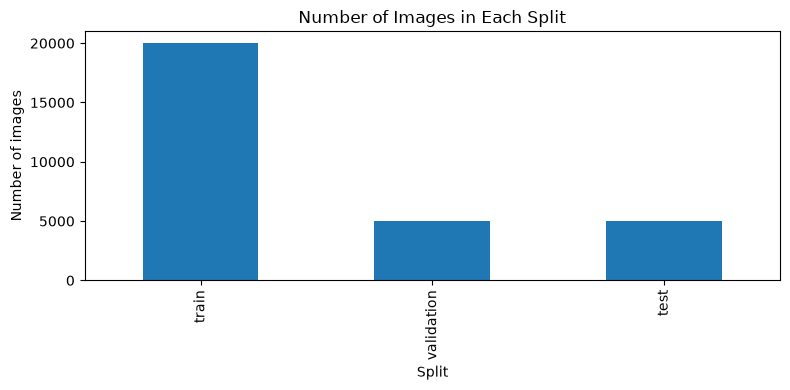

In [9]:
fig, ax = plt.subplots(figsize=(8, 4))
summary_df.plot(x="split", y="num_images", kind="bar", legend=False, ax=ax)
ax.set_title("Number of Images in Each Split")
ax.set_ylabel("Number of images")
ax.set_xlabel("Split")
plt.tight_layout()
plt.show()

## 6. Check project label mapping

All models should use `class_idx` as the label.  
The original iNaturalist `category_id` is kept only for reference and should not be used as the model label.


In [10]:
class_to_idx_path = split_dir / "class_to_idx.json"
idx_to_class_path = split_dir / "idx_to_class.json"

with open(class_to_idx_path, "r", encoding="utf-8") as f:
    class_to_idx = json.load(f)

with open(idx_to_class_path, "r", encoding="utf-8") as f:
    idx_to_class = json.load(f)

print("Number of classes in class_to_idx:", len(class_to_idx))
print("Number of classes in idx_to_class:", len(idx_to_class))
print("\nFirst 10 class mappings:")

for i, (label, idx) in enumerate(list(class_to_idx.items())[:10]):
    print(f"{idx:3d} -> {label}")

Number of classes in class_to_idx: 500
Number of classes in idx_to_class: 500

First 10 class mappings:
  0 -> 44
  1 -> 46
  2 -> 53
  3 -> 70
  4 -> 83
  5 -> 89
  6 -> 109
  7 -> 110
  8 -> 147
  9 -> 170


## 7. Image path checking

The split CSV files store project-relative image paths, such as:

```text
data/raw/train_mini/...
data/raw/val/...
```

The following cell checks a sample of paths from each split.


In [11]:
def resolve_path(path_str):
    p = Path(path_str)
    if p.is_absolute():
        return p
    return PROJECT_ROOT / p

def check_paths(df, name, sample_size=200):
    sample_paths = df["image_path"].sample(min(sample_size, len(df)), random_state=9517).tolist()
    missing = [p for p in sample_paths if not resolve_path(p).exists()]
    print(f"{name}: checked {len(sample_paths)} sampled paths")
    print(f"{name}: missing paths = {len(missing)}")
    if missing:
        print("First missing examples:", missing[:5])

check_paths(train_df, "train")
check_paths(val_df, "validation")
check_paths(test_df, "test")

train: checked 200 sampled paths
train: missing paths = 0
validation: checked 200 sampled paths
validation: missing paths = 0
test: checked 200 sampled paths
test: missing paths = 0


## 8. Visualise sample images from the selected subset

These images are loaded directly from the paths in the fixed split CSV files.


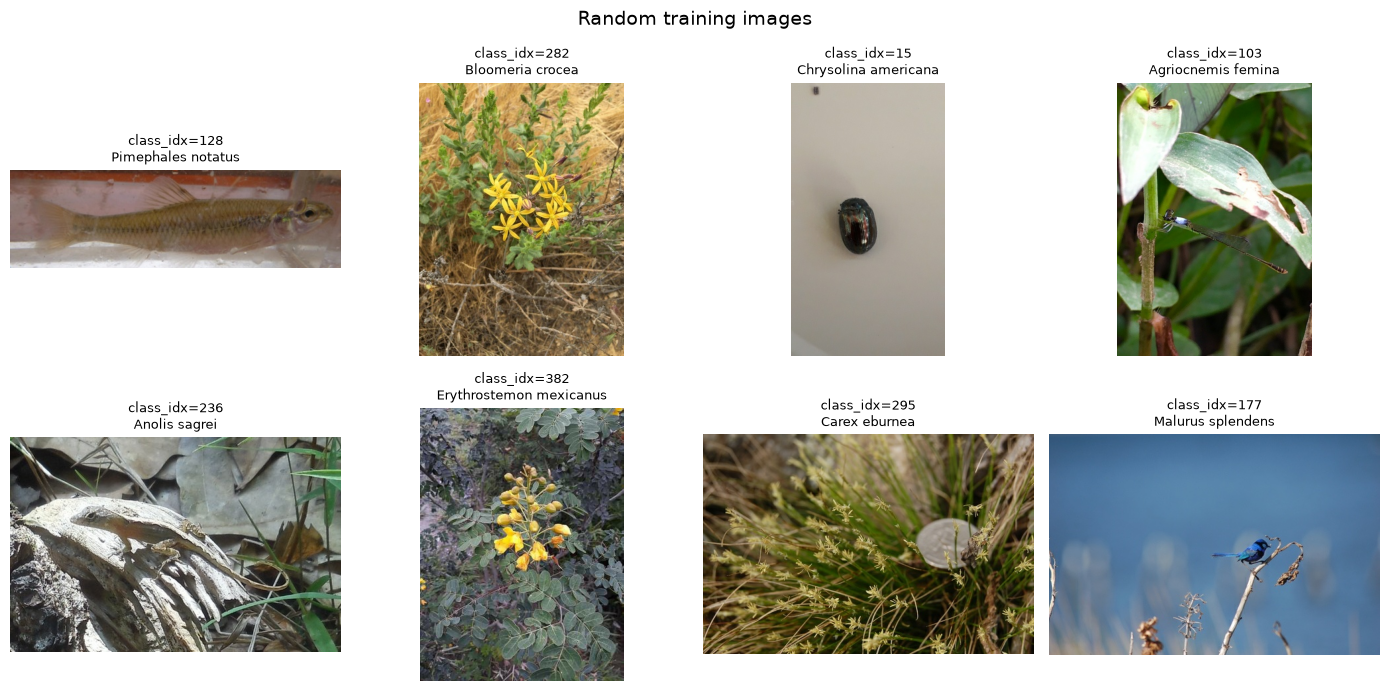

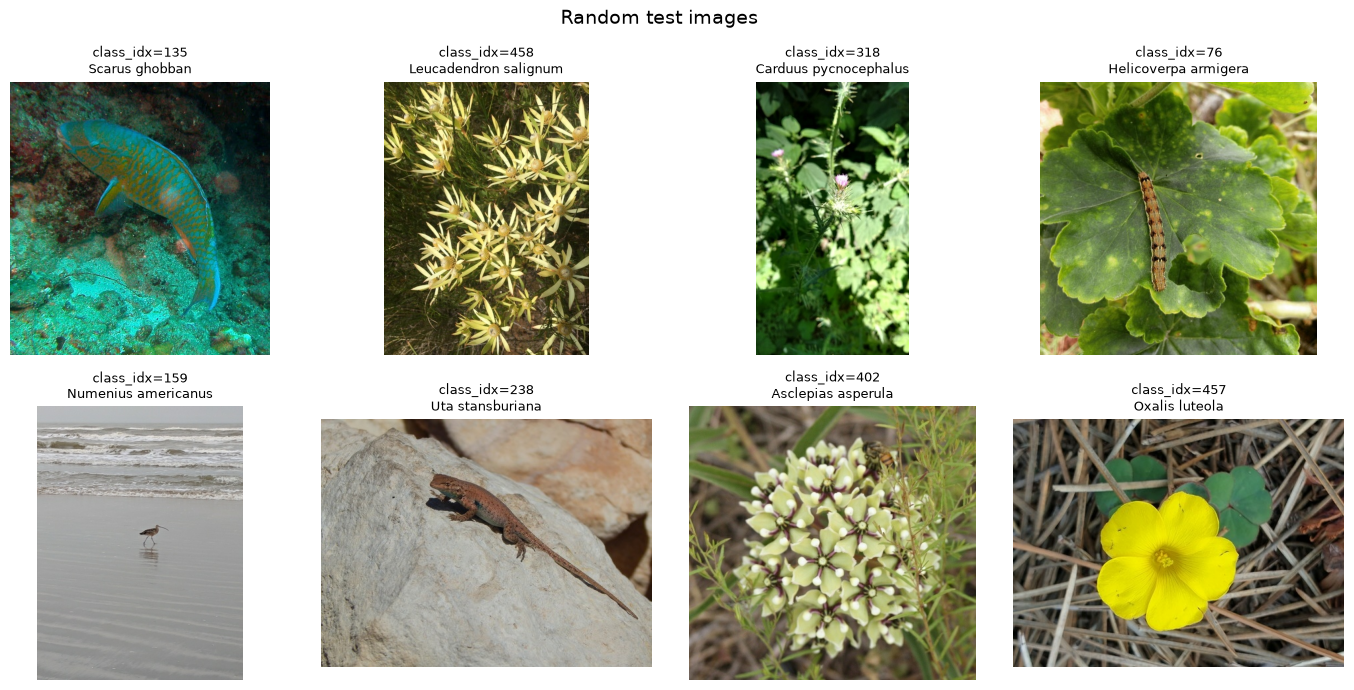

In [12]:
def show_samples(df, title, n=8, random_state=9517):
    sample = df.sample(n=min(n, len(df)), random_state=random_state)
    cols = 4
    rows = int(np.ceil(len(sample) / cols))
    fig, axes = plt.subplots(rows, cols, figsize=(14, 3.5 * rows))
    axes = np.array(axes).reshape(-1)

    for ax, (_, row) in zip(axes, sample.iterrows()):
        img = Image.open(resolve_path(row["image_path"])).convert("RGB")
        ax.imshow(img)
        ax.set_title(f'class_idx={row["class_idx"]}\n{row["label"]}', fontsize=9)
        ax.axis("off")

    for ax in axes[len(sample):]:
        ax.axis("off")

    plt.suptitle(title, fontsize=14)
    plt.tight_layout()
    plt.show()

show_samples(train_df, "Random training images", n=8)
show_samples(test_df, "Random test images", n=8)

## 9. Test the shared PyTorch dataloader

C and D can use `src.dataset.make_loader` for deep learning models.

The training loader uses online augmentation when `augment=True`.  
Validation and test loaders should use `augment=False`.


In [13]:
try:
    from src.dataset import make_loader, IMAGENET_MEAN, IMAGENET_STD

    train_loader = make_loader(
        csv_path=train_csv,
        split="train",
        batch_size=8,
        image_size=224,
        num_workers=0,
        augment=True
    )

    images, labels = next(iter(train_loader))
    print("images shape:", images.shape)
    print("labels shape:", labels.shape)
    print("labels:", labels.tolist())

except Exception as e:
    print("Dataloader test failed.")
    print(type(e).__name__ + ":", e)

images shape: torch.Size([8, 3, 224, 224])
labels shape: torch.Size([8])
labels: [418, 409, 290, 339, 282, 84, 323, 141]


## 10. Visualise one dataloader batch

The dataloader normalises images using ImageNet mean and standard deviation.  
For display only, the following cell reverses the normalisation.


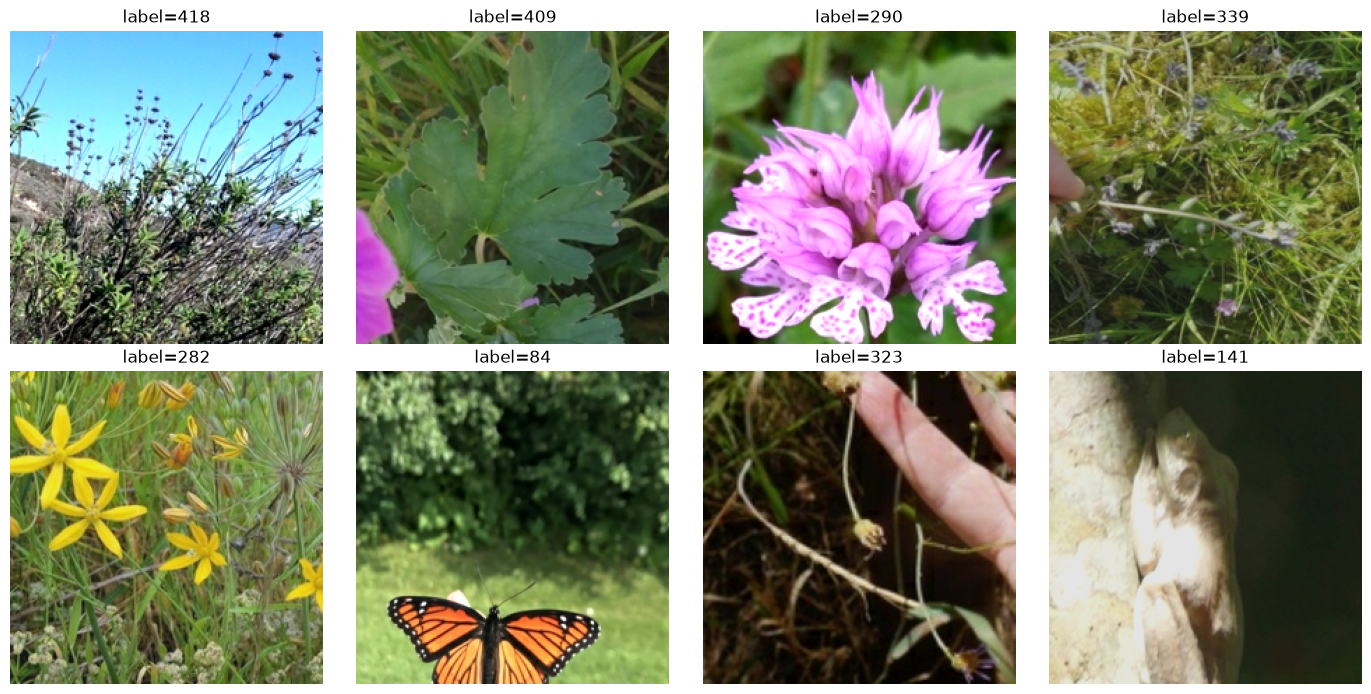

In [14]:
try:
    mean = np.array(IMAGENET_MEAN).reshape(3, 1, 1)
    std = np.array(IMAGENET_STD).reshape(3, 1, 1)

    imgs = images.detach().cpu().numpy()
    labels_np = labels.detach().cpu().numpy()

    fig, axes = plt.subplots(2, 4, figsize=(14, 7))
    axes = axes.reshape(-1)

    for i, ax in enumerate(axes):
        img = imgs[i] * std + mean
        img = np.clip(img.transpose(1, 2, 0), 0, 1)
        ax.imshow(img)
        ax.set_title(f"label={labels_np[i]}")
        ax.axis("off")

    plt.tight_layout()
    plt.show()

except Exception as e:
    print("Batch visualisation skipped.")
    print(type(e).__name__ + ":", e)

## 11. Test-time degradation examples for robustness

The robustness experiment evaluates trained models on degraded test images.

Supported degradations:

- Gaussian noise
- Gaussian blur
- Brightness change
- Contrast change
- JPEG compression

These examples are saved under:

```text
results/figures/degradation_test/
```

These images are for visual explanation only and should not be included in the final code zip if the submission size is restricted.


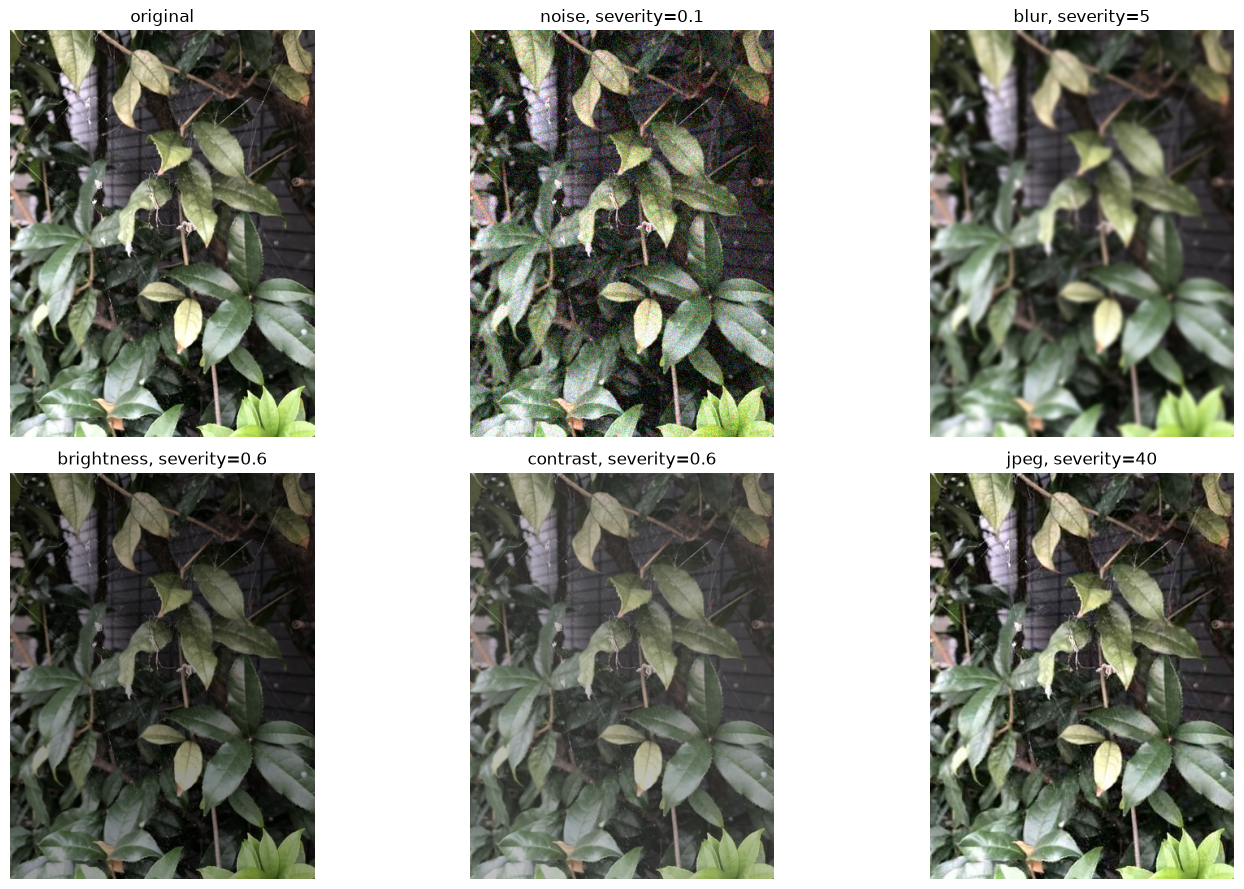

Saved degradation examples to: d:\Code\unsw\comp9517\COMP9517_Project\results\figures\degradation_test
Original image: d:\Code\unsw\comp9517\COMP9517_Project\data\raw\val\00044_Animalia_Arthropoda_Arachnida_Araneae_Araneidae_Trichonephila_clavata\b118ce80-030d-4215-8655-a1e737a8ea09.jpg
Original size: (375, 500)


In [15]:
from src.degradations import apply_degradation

out_dir = PROJECT_ROOT / "results" / "figures" / "degradation_test"
out_dir.mkdir(parents=True, exist_ok=True)

img_path = resolve_path(test_df.iloc[0]["image_path"])
img = Image.open(img_path).convert("RGB")

settings = [
    ("original", None),
    ("noise", 0.10),
    ("blur", 5),
    ("brightness", 0.6),
    ("contrast", 0.6),
    ("jpeg", 40),
]

fig, axes = plt.subplots(2, 3, figsize=(15, 9))
axes = axes.reshape(-1)

for ax, (name, severity) in zip(axes, settings):
    if name == "original":
        shown = img
        save_name = "original.jpg"
        title = "original"
    else:
        shown = apply_degradation(img, name, severity)
        save_name = f"{name}_{severity}.jpg"
        title = f"{name}, severity={severity}"

    shown.save(out_dir / save_name)
    ax.imshow(shown)
    ax.set_title(title)
    ax.axis("off")

plt.tight_layout()
plt.show()

print("Saved degradation examples to:", out_dir)
print("Original image:", img_path)
print("Original size:", img.size)

## 12. Summary

This notebook documents Member A's first-stage contribution:

- Raw data placement was checked.
- The original split-generation command was recorded.
- The fixed 500-class split was loaded from `data/splits/`.
- Train/validation/test sizes and class distributions were inspected.
- Project label mapping was checked.
- Image paths were checked.
- Sample images were displayed.
- The shared dataloader was tested.
- Robustness degradation examples were generated.

The next Member A notebook is:

```text
notebooks/A2_evaluation_and_robustness_summary.ipynb
```

That notebook should be completed after B/C/D provide their model prediction CSV files.
